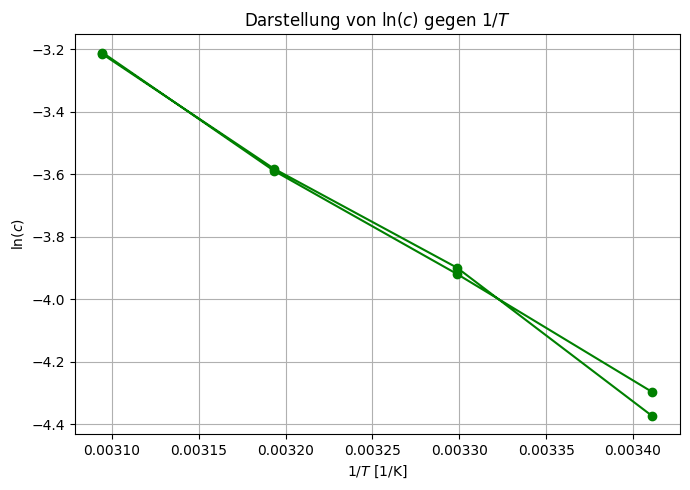

          c  T_C     T_K       1/T      ln_c
0  0.013608   20  293.15  0.003411 -4.297097
1  0.019858   30  303.15  0.003299 -3.919168
2  0.027619   40  313.15  0.003193 -3.589244
3  0.040320   50  323.15  0.003095 -3.210908
4  0.040118   50  323.15  0.003095 -3.215920
5  0.027801   40  313.15  0.003193 -3.582696
6  0.020261   30  303.15  0.003299 -3.899067
7  0.012600   20  293.15  0.003411 -4.374058


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei einlesen
# ===============================
xls_file = pd.ExcelFile("Exp5_Loeslichkeit_Template2025.xls", engine="xlrd")

# Daten aus "Tabelle1", Spalten F (c) und I (T), ab Zeile 8 (Excel) → skiprows=7
df = pd.read_excel(
    xls_file,
    sheet_name="Tabelle1",
    usecols="F,I",      # Spalten: Konzentration, Temperatur
    skiprows=7,
    nrows=8
)

# ===============================
# Spaltennamen setzen
# ===============================
df.columns = ["c", "T_C"]
df = df.dropna()  # Entfernt leere Zeilen

# ===============================
# Umrechnung & Logarithmus
# ===============================
df["T_K"] = df["T_C"] + 273.15          # Umrechnung in Kelvin
df["1/T"] = 1 / df["T_K"]               # Kehrwert der Temperatur
df["ln_c"] = np.log(df["c"])            # Natürlicher Logarithmus der Konzentration

# ===============================
# Plot: ln(c) vs. 1/T
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(df["1/T"], df["ln_c"], 'o-', color='green')
plt.xlabel(r"$1/T$ [1/K]")
plt.ylabel(r"$\ln(c)$")
plt.title(r"Darstellung von $\ln(c)$ gegen $1/T$")
plt.grid(True)
plt.tight_layout()
plt.show()

# ===============================
# Ausgabe zur Kontrolle
# ===============================
print(df)

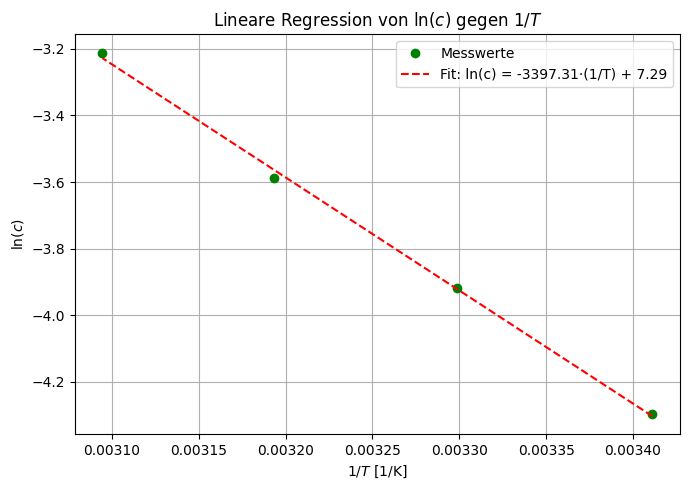

          c  T_C     T_K       1/T      ln_c
0  0.013608   20  293.15  0.003411 -4.297097
1  0.019858   30  303.15  0.003299 -3.919168
2  0.027619   40  313.15  0.003193 -3.589244
3  0.040320   50  323.15  0.003095 -3.210908

Lineare Regressionsergebnisse:
Steigung (a): -3397.3139
Achsenabschnitt (b): 7.2853


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei einlesen
# ===============================
xls_file = pd.ExcelFile("Exp5_Loeslichkeit_Template2025.xls", engine="xlrd")

df = pd.read_excel(
    xls_file,
    sheet_name="Tabelle1",
    usecols="F,I",      # Spalten: Konzentration, Temperatur
    skiprows=7,
    nrows=4
)

# ===============================
# Spaltennamen & Umrechnungen
# ===============================
df.columns = ["c", "T_C"]
df = df.dropna()
df["T_K"] = df["T_C"] + 273.15
df["1/T"] = 1 / df["T_K"]
df["ln_c"] = np.log(df["c"])

# ===============================
# Lineare Regression
# ===============================
x = df["1/T"].values
y = df["ln_c"].values
slope, intercept = np.polyfit(x, y, 1)
y_fit = slope * x + intercept

# ===============================
# Plot mit Regressionsgerade
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', label='Messwerte', color='green')
plt.plot(x, y_fit, '--', label=f'Fit: ln(c) = {slope:.2f}·(1/T) + {intercept:.2f}', color='red')

plt.xlabel(r"$1/T$ [1/K]")
plt.ylabel(r"$\ln(c)$")
plt.title(r"Lineare Regression von $\ln(c)$ gegen $1/T$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ergebnisse ausgeben
# ===============================
print(df)
print(f"\nLineare Regressionsergebnisse:")
print(f"Steigung (a): {slope:.4f}")
print(f"Achsenabschnitt (b): {intercept:.4f}")

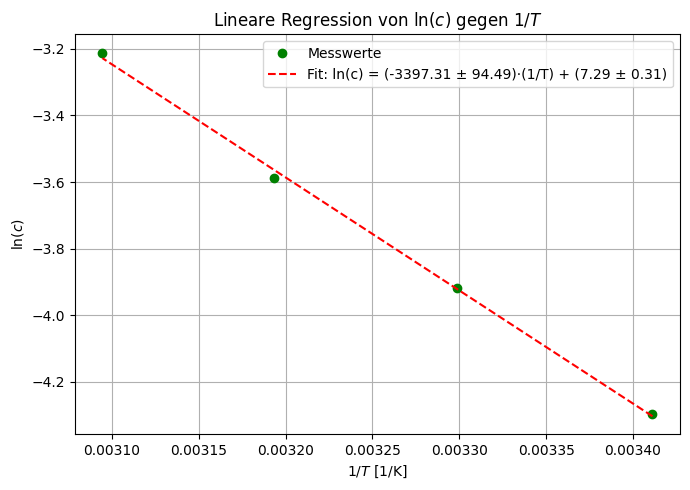

          c  T_C     T_K       1/T      ln_c
0  0.013608   20  293.15  0.003411 -4.297097
1  0.019858   30  303.15  0.003299 -3.919168
2  0.027619   40  313.15  0.003193 -3.589244
3  0.040320   50  323.15  0.003095 -3.210908

=== Regressionsanalyse ===
Steigung (a): -3397.3139 ± 94.4861
Achsenabschnitt (b): 7.2853 ± 0.3072
Bestimmtheitsmaß R²: 0.9985

=== Thermodynamische Deutung ===
ΔH = 3397.3139 * R = 28245.27 ± 785.56 J/mol


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# ===============================
# Excel-Datei einlesen
# ===============================
xls_file = pd.ExcelFile("Exp5_Loeslichkeit_Template2025.xls", engine="xlrd")

df = pd.read_excel(
    xls_file,
    sheet_name="Tabelle1",
    usecols="F,I",      # Spalten: Konzentration, Temperatur
    skiprows=7,
    nrows=4
)

# ===============================
# Spaltennamen & Umrechnungen
# ===============================
df.columns = ["c", "T_C"]
df = df.dropna()
df["T_K"] = df["T_C"] + 273.15
df["1/T"] = 1 / df["T_K"]
df["ln_c"] = np.log(df["c"])

# ===============================
# Lineare Regression mit Fehlern
# ===============================
x = df["1/T"].values
y = df["ln_c"].values

reg_result = linregress(x, y)

slope = reg_result.slope
intercept = reg_result.intercept
slope_err = reg_result.stderr
intercept_err = reg_result.intercept_stderr
r_value = reg_result.rvalue

y_fit = slope * x + intercept

# ===============================
# Plot mit Regressionsgerade
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', label='Messwerte', color='green')
plt.plot(x, y_fit, '--', label=f'Fit: ln(c) = ({slope:.2f} ± {slope_err:.2f})·(1/T) + ({intercept:.2f} ± {intercept_err:.2f})', color='red')

plt.xlabel(r"$1/T$ [1/K]")
plt.ylabel(r"$\ln(c)$")
plt.title(r"Lineare Regression von $\ln(c)$ gegen $1/T$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Ausgabe der Ergebnisse
# ===============================
print(df)

print("\n=== Regressionsanalyse ===")
print(f"Steigung (a): {slope:.4f} ± {slope_err:.4f}")
print(f"Achsenabschnitt (b): {intercept:.4f} ± {intercept_err:.4f}")
print(f"Bestimmtheitsmaß R²: {r_value**2:.4f}")

# ===============================
# Thermodynamik (optional)
# ===============================
R = 8.314  # J/mol·K
delta_H = -slope * R
delta_H_err = slope_err * R

print(f"\n=== Thermodynamische Deutung ===")
print(f"ΔH = {-slope:.4f} * R = {delta_H:.2f} ± {delta_H_err:.2f} J/mol")

In [5]:
# ===============================
# c_unendlich berechnen
# ===============================
c_inf = np.exp(intercept)
c_inf_err = c_inf * intercept_err  # Gaußsche Fehlerfortpflanzung

print(f"\n=== Grenzkonzentration ===")
print(f"c_∞ = exp(b) = {c_inf:.4e} ± {c_inf_err:.4e} mol/L")


=== Grenzkonzentration ===
c_∞ = exp(b) = 1.4587e+03 ± 4.4816e+02 mol/L
